# NFL Big Data Bowl 2025 — Player Tracking Explorer

Visualize player positions, routes, and full play animations from NFL tracking data.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
from matplotlib import colormaps
from IPython.display import HTML

# Load metadata
games = pd.read_csv('data/games.csv')
plays = pd.read_csv('data/plays.csv')
players = pd.read_csv('data/players.csv')
player_play = pd.read_csv('data/player_play.csv')

# Load only week 1 tracking to start (others are large)
tracking = pd.read_csv('data/tracking_week_1.csv')

print(f"Games: {games.shape}")
print(f"Plays: {plays.shape}")
print(f"Players: {players.shape}")
print(f"Player-Play: {player_play.shape}")
print(f"Tracking (week 1): {tracking.shape}")
print()
print("Sample tracking data:")
tracking.head()

Games: (136, 9)
Plays: (16124, 50)
Players: (1697, 7)
Player-Play: (354727, 50)
Tracking (week 1): (7104700, 18)

Sample tracking data:


,gameId,playId,nflId,displayName,frameId,frameType,time,jerseyNumber,club,playDirection,x,y,s,a,dis,o,dir,event
0,2022091200,64,35459.0,Kareem Jackson,1,BEFORE_SNAP,2022-09-13 00:16:03.5,22.0,DEN,right,51.06,28.55,0.72,0.37,0.07,246.17,68.34,huddle_break_offense
1,2022091200,64,35459.0,Kareem Jackson,2,BEFORE_SNAP,2022-09-13 00:16:03.6,22.0,DEN,right,51.13,28.57,0.71,0.36,0.07,245.41,71.21,NaN
2,2022091200,64,35459.0,Kareem Jackson,3,BEFORE_SNAP,2022-09-13 00:16:03.7,22.0,DEN,right,51.20,28.59,0.69,0.23,0.07,244.45,69.90,NaN
3,2022091200,64,35459.0,Kareem Jackson,4,BEFORE_SNAP,2022-09-13 00:16:03.8,22.0,DEN,right,51.26,28.62,0.67,0.22,0.07,244.45,67.98,NaN
4,2022091200,64,35459.0,Kareem Jackson,5,BEFORE_SNAP,2022-09-13 00:16:03.9,22.0,DEN,right,51.32,28.65,0.65,0.34,0.07,245.74,62.83,NaN


## Football Field Drawing Helper

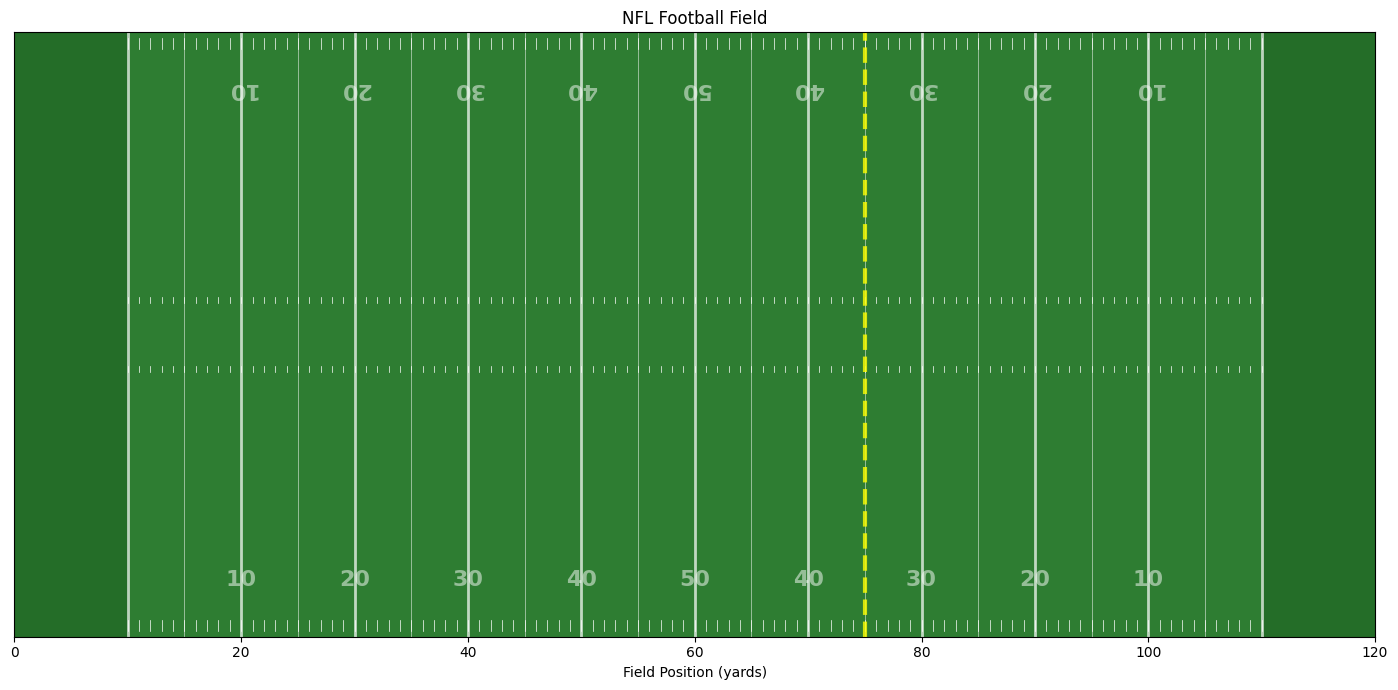

In [15]:
def draw_field(ax, highlight_line=None):
    """Draw a football field on the given axes."""
    ax.set_facecolor('#2e7d32')
    
    # Field boundaries
    ax.set_xlim(0, 120)
    ax.set_ylim(0, 53.3)
    
    # Yard lines every 5 yards
    for x in range(10, 111, 5):
        lw = 2 if x % 10 == 0 else 0.5
        ax.axvline(x, color='white', linewidth=lw, alpha=0.7)
    
    # End zones
    ax.axvspan(0, 10, color='#1b5e20', alpha=0.5)
    ax.axvspan(110, 120, color='#1b5e20', alpha=0.5)
    
    # Yard numbers
    for yard in range(10, 100, 10):
        num = yard if yard <= 50 else 100 - yard
        ax.text(yard + 10, 5, str(num), fontsize=16, color='white',
                ha='center', va='center', fontweight='bold', alpha=0.5)
        ax.text(yard + 10, 48.3, str(num), fontsize=16, color='white',
                ha='center', va='center', fontweight='bold', alpha=0.5, rotation=180)
    
    # Hash marks
    for x in range(10, 111):
        ax.plot([x, x], [0.5, 1.5], color='white', linewidth=0.5)
        ax.plot([x, x], [51.8, 52.8], color='white', linewidth=0.5)
        ax.plot([x, x], [23.36, 23.86], color='white', linewidth=0.5)
        ax.plot([x, x], [29.44, 29.94], color='white', linewidth=0.5)
    
    # Line of scrimmage
    if highlight_line:
        ax.axvline(highlight_line, color='yellow', linewidth=3, alpha=0.8, linestyle='--')
    
    ax.set_xlabel('Field Position (yards)')
    ax.set_ylabel('')
    ax.set_yticks([])
    ax.set_aspect('equal')
    
    return ax

# Test it
fig, ax = plt.subplots(figsize=(16, 7))
draw_field(ax, highlight_line=75)
ax.set_title('NFL Football Field')
plt.tight_layout()
plt.show()

## Single Play Visualization — All 22 Players at the Snap

Game: WAS vs JAX
Play: (2:00) (Shotgun) C.Wentz pass short left to A.Gibson to JAX 39 for 25 yards (F.Oluokun).
Formation: SHOTGUN, Receiver Alignment: 2x2
Down & Distance: 3 & 1


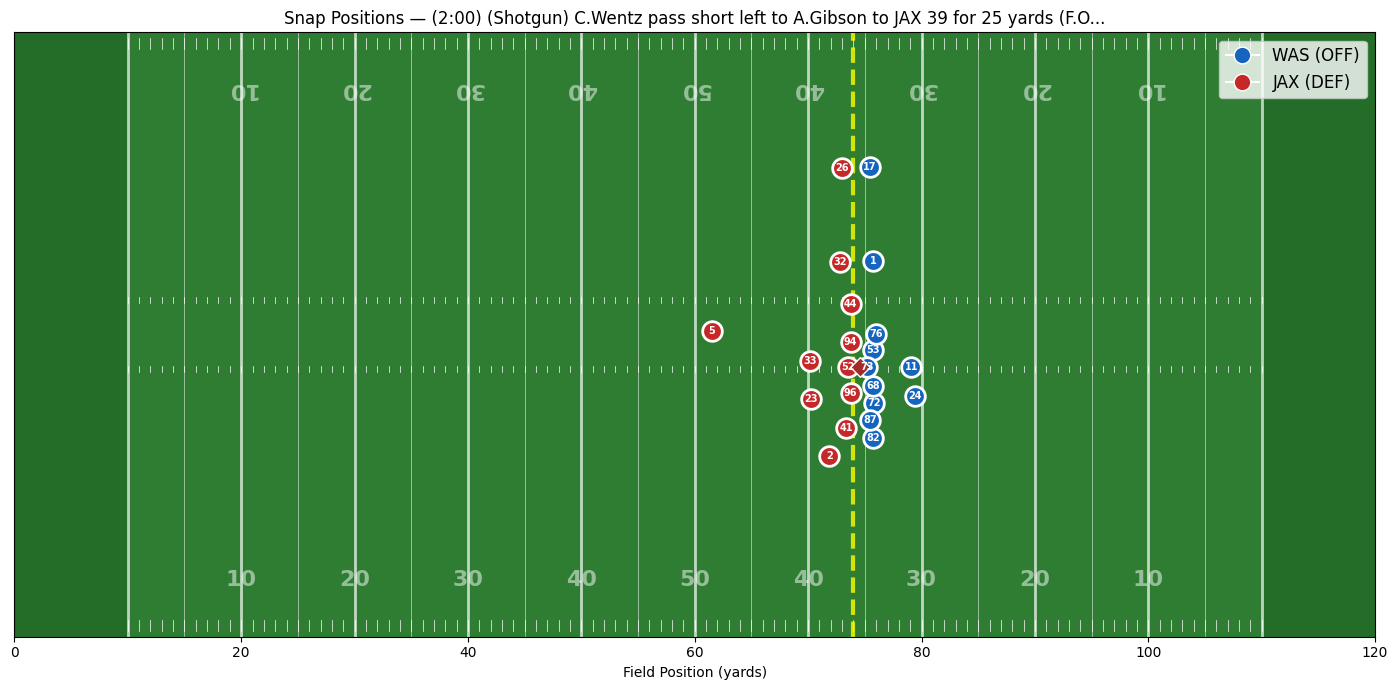

In [16]:
# Find a passing play
pass_plays = plays[plays['passResult'].isin(['C', 'I'])].merge(games[games['week'] == 1], on='gameId')
sample_play = pass_plays.iloc[5]
game_id, play_id = sample_play['gameId'], sample_play['playId']
los = sample_play['absoluteYardlineNumber']

print(f"Game: {sample_play['homeTeamAbbr']} vs {sample_play['visitorTeamAbbr']}")
print(f"Play: {sample_play['playDescription']}")
print(f"Formation: {sample_play['offenseFormation']}, Receiver Alignment: {sample_play['receiverAlignment']}")
print(f"Down & Distance: {sample_play['down']} & {sample_play['yardsToGo']}")

# Get snap frame
play_tracking = tracking[(tracking['gameId'] == game_id) & (tracking['playId'] == play_id)]
snap_frame = play_tracking[play_tracking['event'] == 'ball_snap']['frameId'].iloc[0]
snap_data = play_tracking[play_tracking['frameId'] == snap_frame]

# Plot
offense_team = sample_play['possessionTeam']
defense_team = sample_play['defensiveTeam']

fig, ax = plt.subplots(figsize=(16, 7))
draw_field(ax, highlight_line=los)

for _, row in snap_data.iterrows():
    if row['club'] == 'football':
        ax.scatter(row['x'], row['y'], c='brown', s=100, zorder=10, edgecolors='white', marker='D')
    elif row['club'] == offense_team:
        ax.scatter(row['x'], row['y'], c='#1565c0', s=200, zorder=10, edgecolors='white', linewidths=2)
        ax.text(row['x'], row['y'], str(int(row['jerseyNumber'])), fontsize=7,
                ha='center', va='center', color='white', fontweight='bold', zorder=11)
    else:
        ax.scatter(row['x'], row['y'], c='#c62828', s=200, zorder=10, edgecolors='white', linewidths=2)
        ax.text(row['x'], row['y'], str(int(row['jerseyNumber'])), fontsize=7,
                ha='center', va='center', color='white', fontweight='bold', zorder=11)

ax.legend([plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#1565c0', markersize=12),
           plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#c62828', markersize=12)],
          [f'{offense_team} (OFF)', f'{defense_team} (DEF)'], loc='upper right', fontsize=12)
ax.set_title(f"Snap Positions — {sample_play['playDescription'][:80]}...", fontsize=12)
plt.tight_layout()
plt.show()

## Route Visualization — Receiver Paths from Snap to Pass Arrival

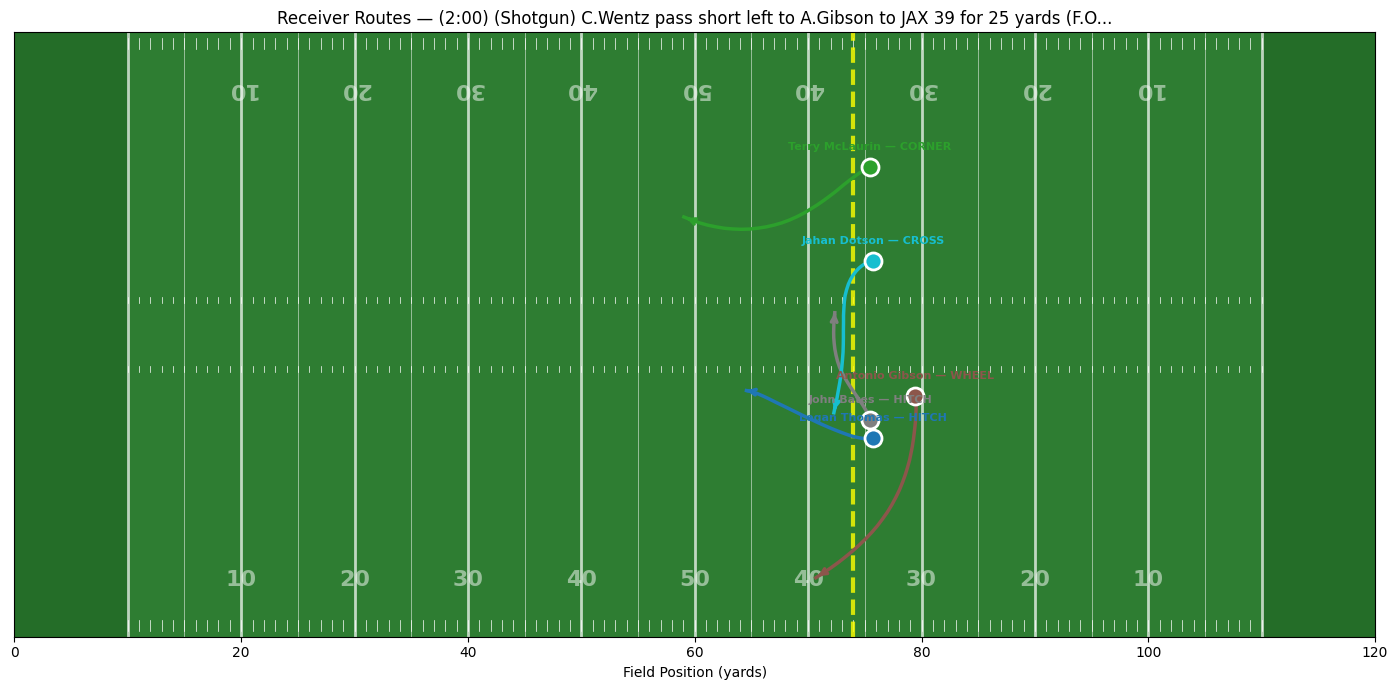

In [17]:
# Get route runners for this play
play_pp = player_play[(player_play['gameId'] == game_id) & (player_play['playId'] == play_id)]
route_runners = play_pp[play_pp['wasRunningRoute'] == 1][['nflId', 'routeRan']]

# Get frames from snap to pass_arrived (or end of play)
events = play_tracking.dropna(subset=['event'])
pass_event = events[events['event'].isin(['pass_arrived', 'pass_outcome_caught',
                                           'pass_outcome_incomplete', 'pass_outcome_interception'])]
if len(pass_event) > 0:
    end_frame = pass_event['frameId'].iloc[0]
else:
    end_frame = play_tracking['frameId'].max()

route_data = play_tracking[
    (play_tracking['frameId'] >= snap_frame) &
    (play_tracking['frameId'] <= end_frame) &
    (play_tracking['nflId'].isin(route_runners['nflId']))
]

# Plot routes
fig, ax = plt.subplots(figsize=(16, 7))
draw_field(ax, highlight_line=los)

colors = plt.cm.tab10(np.linspace(0, 1, len(route_runners)))
for (nfl_id, route), color in zip(route_runners.values, colors):
    player_data = route_data[route_data['nflId'] == nfl_id].sort_values('frameId')
    name = player_data['displayName'].iloc[0] if len(player_data) > 0 else str(nfl_id)
    label = f"{name} — {route}" if pd.notna(route) else name
    
    ax.plot(player_data['x'], player_data['y'], color=color, linewidth=2.5, zorder=5)
    # Start position
    ax.scatter(player_data['x'].iloc[0], player_data['y'].iloc[0],
              color=color, s=150, zorder=10, edgecolors='white', linewidths=2)
    # End position (arrow)
    if len(player_data) > 1:
        ax.annotate('', xy=(player_data['x'].iloc[-1], player_data['y'].iloc[-1]),
                    xytext=(player_data['x'].iloc[-2], player_data['y'].iloc[-2]),
                    arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
    ax.text(player_data['x'].iloc[0], player_data['y'].iloc[0] + 1.5, label,
            fontsize=8, ha='center', color=color, fontweight='bold', zorder=11)

ax.set_title(f"Receiver Routes — {sample_play['playDescription'][:80]}...", fontsize=12)
plt.tight_layout()
plt.show()

## Full Play Animation — All 22 Players Frame-by-Frame

In [18]:
import matplotlib as mpl
mpl.rcParams['animation.ffmpeg_path'] = '/opt/homebrew/bin/ffmpeg'

def animate_play(tracking_df, game_id, play_id, plays_df, interval=100):
    """Animate all 22 players for a given play. Returns HTML5 video."""
    play_info = plays_df[(plays_df['gameId'] == game_id) & (plays_df['playId'] == play_id)].iloc[0]
    play_data = tracking_df[(tracking_df['gameId'] == game_id) & (tracking_df['playId'] == play_id)]
    
    offense = play_info['possessionTeam']
    defense = play_info['defensiveTeam']
    los = play_info['absoluteYardlineNumber']
    frames = sorted(play_data['frameId'].unique())
    
    fig, ax = plt.subplots(figsize=(16, 7))
    
    def update(frame_id):
        ax.clear()
        draw_field(ax, highlight_line=los)
        
        frame_data = play_data[play_data['frameId'] == frame_id]
        event = frame_data['event'].dropna().unique()
        event_text = event[0] if len(event) > 0 else ''
        
        for _, row in frame_data.iterrows():
            if row['club'] == 'football':
                ax.scatter(row['x'], row['y'], c='brown', s=80, zorder=10,
                          edgecolors='white', marker='D')
            elif row['club'] == offense:
                ax.scatter(row['x'], row['y'], c='#1565c0', s=180, zorder=10,
                          edgecolors='white', linewidths=2)
                ax.text(row['x'], row['y'], str(int(row['jerseyNumber'])),
                       fontsize=6, ha='center', va='center', color='white',
                       fontweight='bold', zorder=11)
            else:
                ax.scatter(row['x'], row['y'], c='#c62828', s=180, zorder=10,
                          edgecolors='white', linewidths=2)
                ax.text(row['x'], row['y'], str(int(row['jerseyNumber'])),
                       fontsize=6, ha='center', va='center', color='white',
                       fontweight='bold', zorder=11)
        
        ax.set_title(f"Frame {frame_id} | {event_text}\n{play_info['playDescription'][:90]}", fontsize=11)
    
    anim = FuncAnimation(fig, update, frames=frames, interval=interval, repeat=True)
    plt.close(fig)
    return HTML(anim.to_html5_video())

# Animate the same play
animate_play(tracking, game_id, play_id, plays)

## Route Tree Gallery — All Routes by a Specific Receiver

Showing routes for: Ja'Marr Chase (58 routes in week 1)


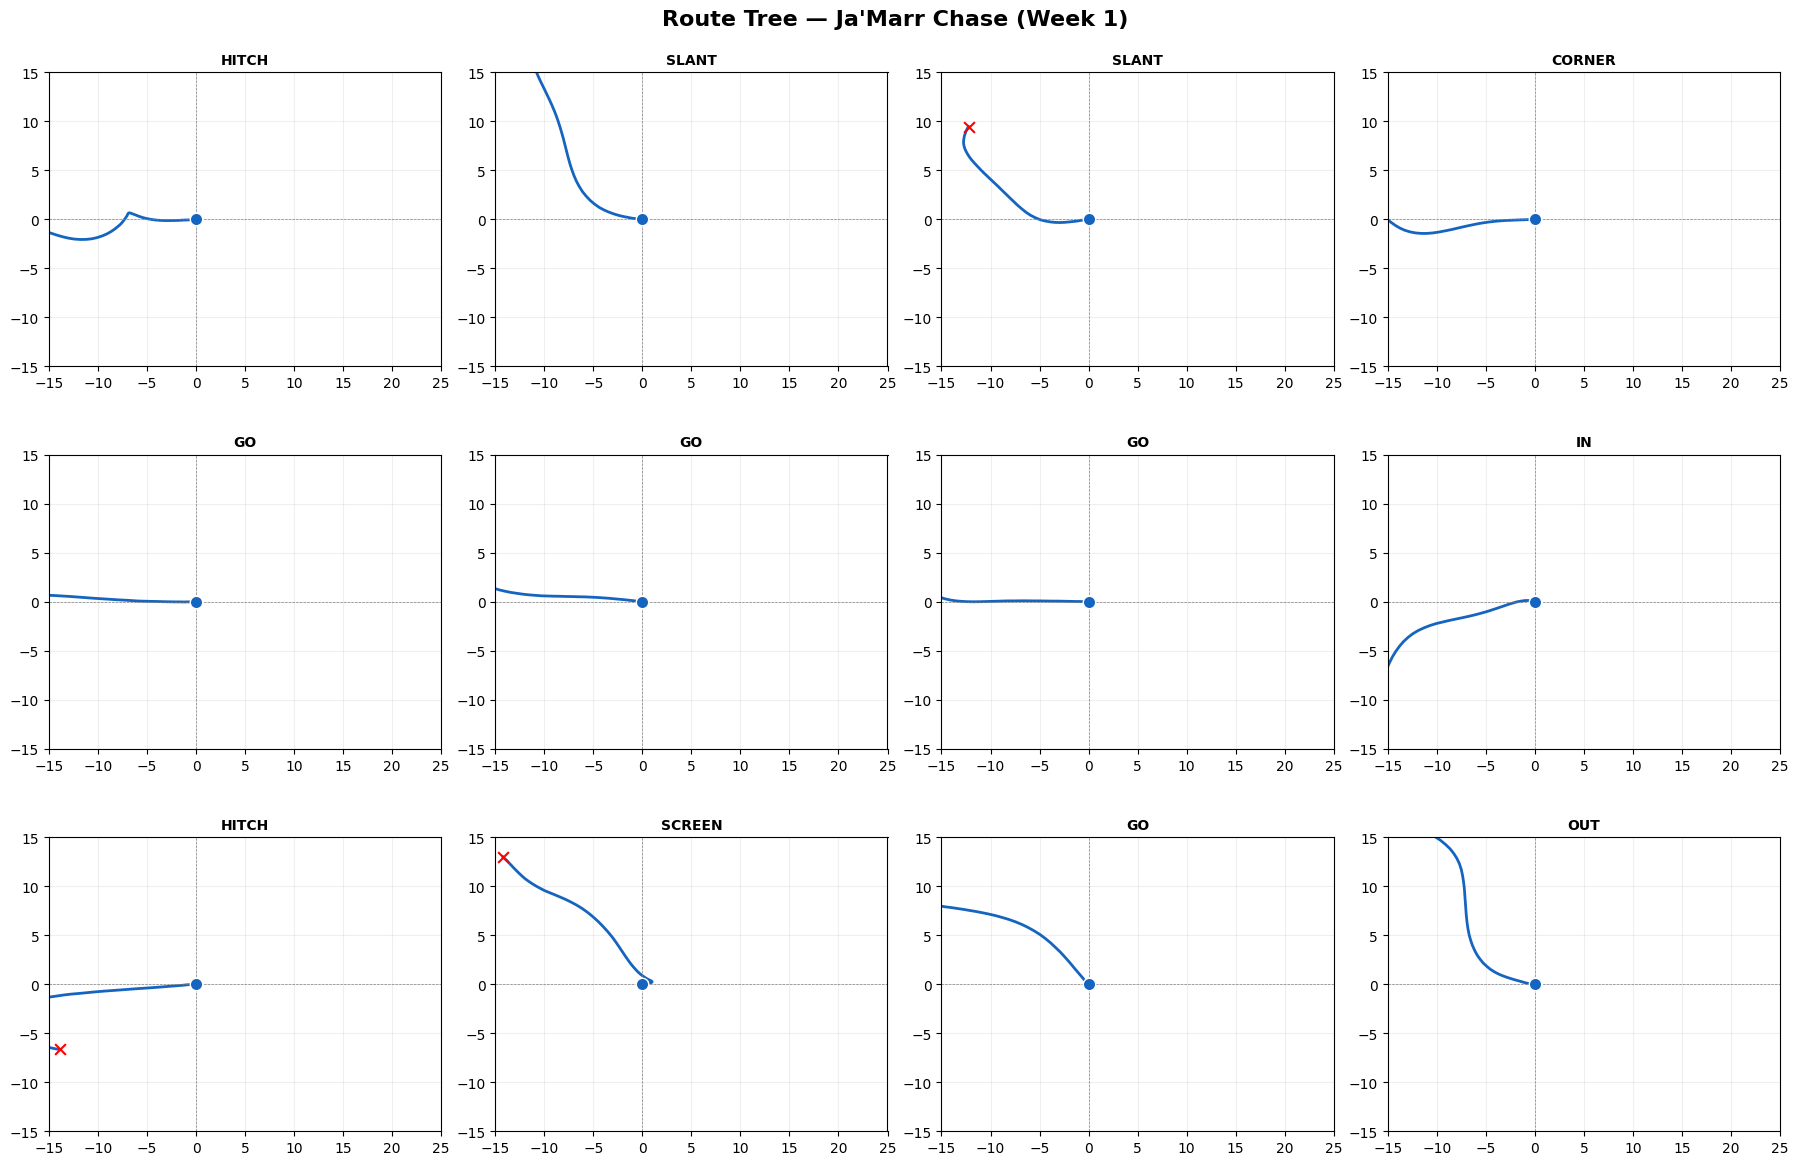

In [19]:
# Find a receiver with many routes in week 1
week1_games = games[games['week'] == 1]['gameId']
week1_pp = player_play[player_play['gameId'].isin(week1_games)]
route_counts = (week1_pp[week1_pp['wasRunningRoute'] == 1]
                .groupby('nflId')['routeRan'].count()
                .sort_values(ascending=False))

target_id = route_counts.index[0]
target_name = players[players['nflId'] == target_id]['displayName'].iloc[0]
print(f"Showing routes for: {target_name} ({route_counts.iloc[0]} routes in week 1)")

# Get all plays where this player ran a route
receiver_plays = week1_pp[(week1_pp['nflId'] == target_id) & (week1_pp['wasRunningRoute'] == 1)]
receiver_plays = receiver_plays.merge(plays[['gameId', 'playId', 'absoluteYardlineNumber']],
                                       on=['gameId', 'playId'])

# Plot each route, normalized so snap position is at origin
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, (_, rplay) in enumerate(receiver_plays.head(12).iterrows()):
    ax = axes[idx]
    gid, pid = rplay['gameId'], rplay['playId']
    
    ptrack = tracking[(tracking['gameId'] == gid) & (tracking['playId'] == pid) & (tracking['nflId'] == target_id)]
    snap_frames = tracking[(tracking['gameId'] == gid) & (tracking['playId'] == pid) & (tracking['event'] == 'ball_snap')]
    if len(snap_frames) == 0:
        continue
    snap_fid = snap_frames['frameId'].iloc[0]
    
    post_snap = ptrack[ptrack['frameId'] >= snap_fid].sort_values('frameId')
    if len(post_snap) == 0:
        continue
    
    # Normalize to snap position
    x0, y0 = post_snap['x'].iloc[0], post_snap['y'].iloc[0]
    xs = post_snap['x'] - x0
    ys = post_snap['y'] - y0
    
    ax.plot(xs, ys, color='#1565c0', linewidth=2)
    ax.scatter(0, 0, c='#1565c0', s=80, zorder=10, edgecolors='white')
    ax.scatter(xs.iloc[-1], ys.iloc[-1], c='red', s=60, zorder=10, marker='x')
    ax.set_title(f"{rplay['routeRan']}", fontsize=10, fontweight='bold')
    ax.set_xlim(-15, 25)
    ax.set_ylim(-15, 15)
    ax.set_aspect('equal')
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.grid(True, alpha=0.2)

# Hide unused axes
for idx in range(len(receiver_plays.head(12)), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle(f"Route Tree — {target_name} (Week 1)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Defensive Formation Classifier — Inferred from Tracking XY Data

In [20]:
# Map player positions to defensive role groups
POS_TO_ROLE = {
    'DE': 'DL', 'DT': 'DL', 'NT': 'DL',
    'OLB': 'LB', 'ILB': 'LB', 'MLB': 'LB', 'LB': 'LB',
    'CB': 'DB', 'FS': 'DB', 'SS': 'DB', 'DB': 'DB',
}

players_pos = players[['nflId', 'position']].copy()
players_pos['defRole'] = players_pos['position'].map(POS_TO_ROLE)

# The 13 canonical formations
FORMATION_MAP = {
    (4, 2, 5): 'Nickel (4-2-5)',
    (3, 3, 5): 'Nickel (3-3-5)',
    (2, 4, 5): 'Nickel (2-4-5)',
    (3, 4, 4): '3-4',
    (4, 3, 4): '4-3',
    (2, 3, 6): 'Dime (2-3-6)',
    (4, 1, 6): 'Dime (4-1-6)',
    (3, 2, 6): 'Dime (3-2-6)',
    (5, 2, 4): '5-2',
    (5, 3, 3): '5-3 Heavy',
    (6, 2, 3): '6-2 Goal Line',
    (4, 4, 3): '4-4',
    (3, 1, 7): 'Quarter',
    (2, 2, 7): 'Quarter',
}

# For non-exact matches, find nearest canonical formation
CANONICAL_KEYS = list(FORMATION_MAP.keys())

def nearest_formation(dl, lb, db):
    """Map any DL-LB-DB combo to the nearest of the 13 formations."""
    exact = FORMATION_MAP.get((dl, lb, db))
    if exact:
        return exact
    # Find closest by Manhattan distance
    best_dist = 999
    best_name = None
    for (cdl, clb, cdb) in CANONICAL_KEYS:
        dist = abs(dl - cdl) + abs(lb - clb) + abs(db - cdb)
        if dist < best_dist:
            best_dist = dist
            best_name = FORMATION_MAP[(cdl, clb, cdb)]
    return best_name

def classify_all_plays(tracking_df, plays_df, players_pos_df=players_pos):
    """Classify defensive formation for all plays in a tracking dataframe."""
    # Pre-merge positions onto tracking for speed
    tracking_with_pos = tracking_df.merge(players_pos_df[['nflId', 'defRole']], on='nflId', how='left')
    
    # Get snap frames only
    snaps = tracking_with_pos[tracking_with_pos['event'] == 'ball_snap'][['gameId', 'playId', 'frameId']].drop_duplicates()
    snap_data = tracking_with_pos.merge(snaps, on=['gameId', 'playId', 'frameId'])
    
    # Get defensive team per play
    def_teams = plays_df[['gameId', 'playId', 'defensiveTeam']].copy()
    snap_data = snap_data.merge(def_teams, on=['gameId', 'playId'])
    
    # Keep only defenders
    snap_def = snap_data[snap_data['club'] == snap_data['defensiveTeam']]
    
    # Count DL, LB, DB per play
    role_counts = snap_def.groupby(['gameId', 'playId', 'defRole']).size().unstack(fill_value=0)
    for col in ['DL', 'LB', 'DB']:
        if col not in role_counts.columns:
            role_counts[col] = 0
    
    role_counts = role_counts[['DL', 'LB', 'DB']].reset_index()
    role_counts['defFormation'] = role_counts.apply(
        lambda r: nearest_formation(r['DL'], r['LB'], r['DB']), axis=1
    )
    return role_counts

# Classify all weeks
print("Classifying defensive formations for all 9 weeks...")
all_formations = []

for week in range(1, 10):
    print(f"  Week {week}...", end=' ')
    if week == 1:
        wk_tracking = tracking  # already loaded
    else:
        wk_tracking = pd.read_csv(f'data/tracking_week_{week}.csv')
    
    wk_result = classify_all_plays(wk_tracking, plays)
    wk_result['week'] = week
    all_formations.append(wk_result)
    print(f"{len(wk_result)} plays")

def_formations = pd.concat(all_formations, ignore_index=True)

print(f"\nTotal plays classified: {len(def_formations)}")
print(f"\nDefensive Formation Distribution (all weeks):")
print(def_formations['defFormation'].value_counts().to_string())

# Save for easy reuse
def_formations.to_csv('data/defensive_formations.csv', index=False)
print("\nSaved to data/defensive_formations.csv")

Classifying defensive formations for all 9 weeks...
  Week 1... 1948 plays
  Week 2... 1805 plays
  Week 3... 1958 plays
  Week 4... 1826 plays
  Week 5... 1902 plays
  Week 6... 1678 plays
  Week 7... 1659 plays
  Week 8... 1762 plays
  Week 9... 1524 plays

Total plays classified: 16062

Defensive Formation Distribution (all weeks):
defFormation
Nickel (4-2-5)    3579
Nickel (3-3-5)    3508
Nickel (2-4-5)    3418
3-4               2053
4-3               1445
Dime (2-3-6)       732
Dime (3-2-6)       494
Dime (4-1-6)       327
5-2                298
Quarter             83
5-3 Heavy           69
6-2 Goal Line       29
4-4                 27

Saved to data/defensive_formations.csv


## Play Type Labels — Combining Pass/Run, Length, and Direction

In [21]:
def label_play_type(row):
    """Create a human-readable play type label like 'Short Pass Right'."""
    # Special plays first
    if str(row['qbSpike']) == 'True':
        return 'QB Spike'
    if row['qbKneel'] == 1:
        return 'QB Kneel'
    if row['qbSneak'] == 1:
        return 'QB Sneak'
    
    # Pass plays
    if row['isDropback']:
        result = row['passResult']
        if result == 'S':
            return 'Sack'
        if result == 'R':
            return 'Scramble'
        
        # Pass length: short (0-9), mid (10-19), deep (20+)
        length = row['passLength']
        if pd.isna(length):
            length_label = 'Pass'
        elif abs(length) <= 9:
            length_label = 'Short Pass'
        elif abs(length) <= 19:
            length_label = 'Mid Pass'
        else:
            length_label = 'Deep Pass'
        
        # Direction
        loc = row['passLocationType']
        if loc == 'OUTSIDE_LEFT':
            return f'{length_label} Left'
        elif loc == 'OUTSIDE_RIGHT':
            return f'{length_label} Right'
        elif loc == 'INSIDE_BOX':
            return f'{length_label} Middle'
        else:
            return length_label
    
    # Run plays
    loc = row['rushLocationType']
    if loc == 'INSIDE_LEFT':
        return 'Run Inside Left'
    elif loc == 'INSIDE_RIGHT':
        return 'Run Inside Right'
    elif loc == 'OUTSIDE_LEFT':
        return 'Run Outside Left'
    elif loc == 'OUTSIDE_RIGHT':
        return 'Run Outside Right'
    else:
        return 'Run'

plays['playType'] = plays.apply(label_play_type, axis=1)

print("Play Type Distribution:")
print(plays['playType'].value_counts().to_string())
print(f"\nTotal plays: {len(plays)}")
print(f"Unique play types: {plays['playType'].nunique()}")

Play Type Distribution:
playType
Short Pass Middle    5333
Run Inside Right     1764
Run Inside Left      1744
Mid Pass Middle      1505
Run Outside Right    1372
Run Outside Left     1223
Deep Pass Middle      790
Sack                  608
Short Pass Right      411
Scramble              400
Mid Pass Right        201
Short Pass Left       183
QB Kneel              165
QB Sneak              120
Mid Pass Left         111
Deep Pass Right        98
Deep Pass Left         71
QB Spike               23
Short Pass              2

Total plays: 16124
Unique play types: 19


## Exploration Helpers — Filter by Team, Player, Route, Week

In [22]:
def load_week(week_num):
    """Load tracking data for a specific week (1-9)."""
    return pd.read_csv(f'data/tracking_week_{week_num}.csv')

def get_team_plays(team_abbr, side='offense'):
    """Get all plays for a team as offense or defense."""
    col = 'possessionTeam' if side == 'offense' else 'defensiveTeam'
    return plays[plays[col] == team_abbr]

def get_player_routes(player_name, week_num=1):
    """Get all route data for a player by name."""
    pid = players[players['displayName'] == player_name]['nflId']
    if len(pid) == 0:
        print(f"Player '{player_name}' not found. Try: {players['displayName'].sample(5).tolist()}")
        return None
    pid = pid.iloc[0]
    pp = player_play[(player_play['nflId'] == pid) & (player_play['wasRunningRoute'] == 1)]
    return pp.merge(plays[['gameId', 'playId', 'playDescription', 'absoluteYardlineNumber',
                           'offenseFormation', 'passResult']], on=['gameId', 'playId'])

def find_plays_by_route(route_type, team=None, week=None):
    """Find plays where a specific route was run (e.g., 'GO', 'SLANT', 'CURL')."""
    mask = player_play['routeRan'] == route_type
    if team:
        mask &= player_play['teamAbbr'] == team
    result = player_play[mask].merge(plays[['gameId', 'playId', 'playDescription']], on=['gameId', 'playId'])
    if week:
        week_games = games[games['week'] == week]['gameId']
        result = result[result['gameId'].isin(week_games)]
    return result

def plot_play(game_id, play_id, tracking_df, show_routes=True):
    """Quick plot of any play — snap positions + optional routes."""
    play_info = plays[(plays['gameId'] == game_id) & (plays['playId'] == play_id)].iloc[0]
    play_data = tracking_df[(tracking_df['gameId'] == game_id) & (tracking_df['playId'] == play_id)]
    snap_fid = play_data[play_data['event'] == 'ball_snap']['frameId'].iloc[0]
    
    fig, ax = plt.subplots(figsize=(16, 7))
    draw_field(ax, highlight_line=play_info['absoluteYardlineNumber'])
    
    offense = play_info['possessionTeam']
    snap = play_data[play_data['frameId'] == snap_fid]
    
    for _, row in snap.iterrows():
        if row['club'] == 'football':
            ax.scatter(row['x'], row['y'], c='brown', s=80, zorder=10, edgecolors='white', marker='D')
        else:
            color = '#1565c0' if row['club'] == offense else '#c62828'
            ax.scatter(row['x'], row['y'], c=color, s=180, zorder=10, edgecolors='white', linewidths=2)
            ax.text(row['x'], row['y'], str(int(row['jerseyNumber'])),
                   fontsize=6, ha='center', va='center', color='white', fontweight='bold', zorder=11)
    
    if show_routes:
        pp = player_play[(player_play['gameId'] == game_id) & (player_play['playId'] == play_id)]
        runners = pp[pp['wasRunningRoute'] == 1]['nflId']
        for nfl_id in runners:
            pdata = play_data[(play_data['nflId'] == nfl_id) & (play_data['frameId'] >= snap_fid)].sort_values('frameId')
            ax.plot(pdata['x'], pdata['y'], linewidth=2, alpha=0.7, zorder=6)
    
    ax.set_title(play_info['playDescription'][:100], fontsize=11)
    plt.tight_layout()
    plt.show()

# Show available teams and route types
print("Available teams:", sorted(plays['possessionTeam'].unique()))
print()
print("Route types:", sorted(player_play['routeRan'].dropna().unique()))
print()
print("Example usage:")
print("  routes = get_player_routes('Tyreek Hill')")
print("  go_routes = find_plays_by_route('GO', team='MIA', week=1)")
print("  plot_play(game_id, play_id, tracking)")
print("  animate_play(tracking, game_id, play_id, plays)")

Available teams: ['ARI', 'ATL', 'BAL', 'BUF', 'CAR', 'CHI', 'CIN', 'CLE', 'DAL', 'DEN', 'DET', 'GB', 'HOU', 'IND', 'JAX', 'KC', 'LA', 'LAC', 'LV', 'MIA', 'MIN', 'NE', 'NO', 'NYG', 'NYJ', 'PHI', 'PIT', 'SEA', 'SF', 'TB', 'TEN', 'WAS']

Route types: ['ANGLE', 'CORNER', 'CROSS', 'FLAT', 'GO', 'HITCH', 'IN', 'OUT', 'POST', 'SCREEN', 'SLANT', 'WHEEL']

Example usage:
  routes = get_player_routes('Tyreek Hill')
  go_routes = find_plays_by_route('GO', team='MIA', week=1)
  plot_play(game_id, play_id, tracking)
  animate_play(tracking, game_id, play_id, plays)
